In [3]:
# Import libraries
import sys
sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")

import os
import xarray as xr
import matplotlib.pyplot as plt

# Chargement des données sauvegardées au format netcdf (.nc)

Les données sont stockées dans le dossier root_data au format netcdf. Le dossier contient deux fichiers : 

- cds_swir_precipitation_2013.nc
- cds_swir_wind_2013.nc

Les données couvrent une zone centrée sur la SWIR de coordonnées : 

- longitude ouest = 64 
- longitude est = 67
- latitude nord = -26
- latitude sud = -29

Les données couvrent les mois de janvier 2013 et mai 2013. 

In [5]:
# Set file paths 
root_data = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\data\cds\cds_swir"       # Remplacer par votre chemin d'accès
fname_precipitation = "cds_swir_precipitation_2013"
fname_wind = "cds_swir_wind_2013"
fpath_precipitation = os.path.join(root_data, fname_precipitation + ".nc")
fpath_wind = os.path.join(root_data, fname_wind + ".nc")

In [7]:
# Load data
ds_precipitation = xr.open_dataset(fpath_precipitation)
ds_wind = xr.open_dataset(fpath_wind)

# Compute wind norm
u_norm = (ds_wind.u10**2 + ds_wind.v10**2) ** 0.5

# Exemple d'affichage de quelques courbes 

## Evolution spatiale

Text(0.5, 1.0, 'Wind (2013-05-31T12:00:00)')

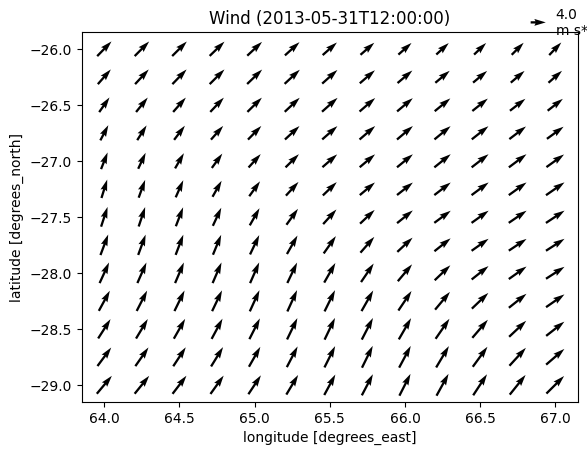

In [12]:
# On peut d'en un premier temps représenter les données à une date donnée
date = "2013-05-31T12:00:00"     # Par exemple le 31/05 à 12h00
# On sélectionne la date dans le dataset de vent
# method="nearest" interpolation dans le cas où il n'y pas de correspondance exacte
ds_wind_date = ds_wind.sel(valid_time=date, method="nearest")   

# Avec un quiver plot
plt.figure()
ds_wind_date.plot.quiver(
    x="longitude",
    y="latitude",
    u="u10",
    v="v10",
)
plt.title(f"Wind ({date})")

Text(0.5, 0.98, 'Wind components and norm (2013-05-31T12:00:00)')

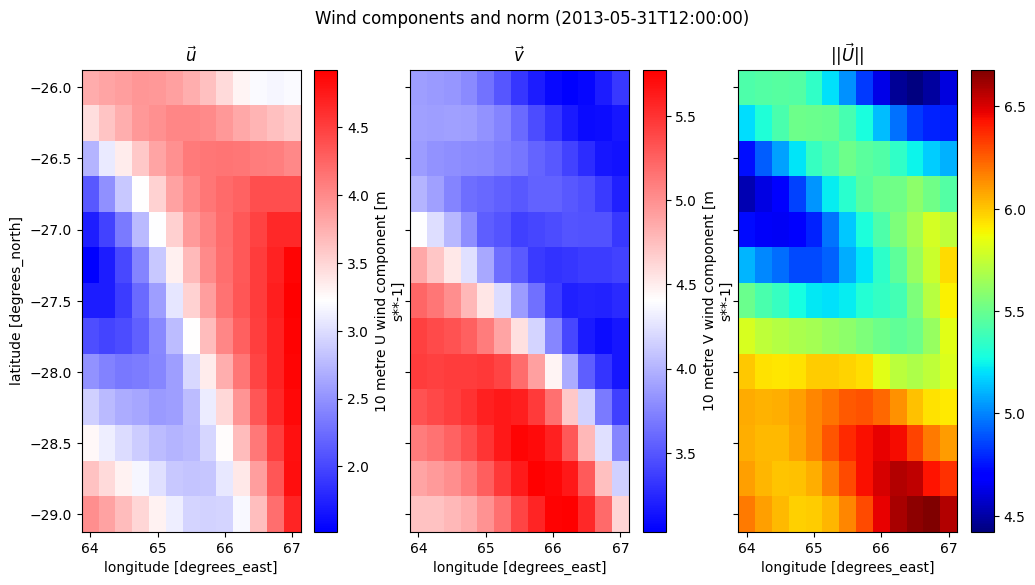

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(12, 6), sharey=True)

ds_wind_date.u10.plot(
    x="longitude",
    y="latitude",
    ax=axs[0],
    cmap="bwr",
)
ds_wind_date.v10.plot(
    x="longitude",
    y="latitude",
    ax=axs[1],
    cmap="bwr",
)

u_norm.sel(valid_time=date, method="nearest").plot(
    x="longitude",
    y="latitude",
    ax=axs[2],
    cmap="jet",
)

axs[1].set_ylabel("")
axs[2].set_ylabel("")
axs[0].set_title(r"$\vec{u}$")
axs[1].set_title(r"$\vec{v}$")
axs[2].set_title(r"$|| \vec{U} ||$")

fig.suptitle(f"Wind components and norm ({date})")

## Evolution temporelle à une position donnée 

Text(0, 0.5, '')

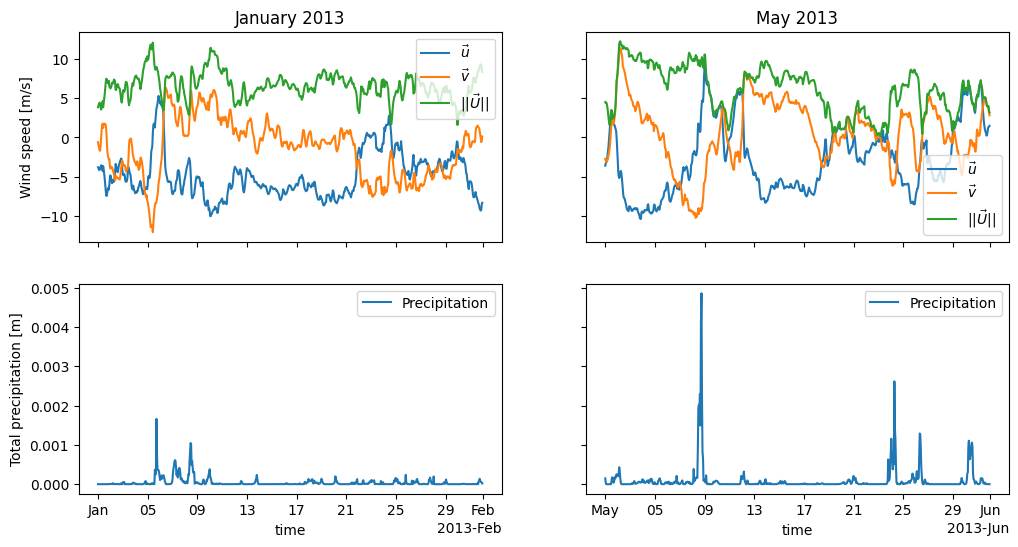

In [24]:
# On selectionne une position pour tracer les séries temporelles
long = 64.5
lat = -27.25
ds_wind_point = ds_wind.sel(
    longitude=long,
    latitude=lat,
    method="nearest"
)
ds_wind_point_janv = ds_wind_point.sel(
    valid_time=slice(
        "2013-01-01T00:00:00",
        "2013-01-31T23:00:00",
    ),
)
ds_wind_point_may = ds_wind_point.sel(
    valid_time=slice(
        "2013-05-01T00:00:00",
        "2013-05-31T23:59:59",
    ),
)
u_norm_point_janv = u_norm.sel(
    longitude=long,
    latitude=lat,
    method="nearest"
).sel(
    valid_time=slice(
        "2013-01-01T00:00:00",
        "2013-01-31T23:00:00",
    ),
)
u_norm_point_may = u_norm.sel(
    longitude=long,
    latitude=lat,
    method="nearest"
).sel(
    valid_time=slice(
        "2013-05-01T00:00:00",
        "2013-05-31T23:59:59",
    ),
)

fig, axs = plt.subplots(2, 2, figsize=(12, 6), sharex="col", sharey="row")

# Mois de janvier
ds_wind_point_janv.u10.plot(label=r"$\vec{u}$", ax=axs[0, 0])
ds_wind_point_janv.v10.plot(label=r"$\vec{v}$", ax=axs[0, 0])
u_norm_point_janv.plot(
    label=r"$|| \vec{U} ||$", ax=axs[0, 0]
)
# Mois de mai
ds_wind_point_may.u10.plot(label=r"$\vec{u}$", ax=axs[0, 1])
ds_wind_point_may.v10.plot(label=r"$\vec{v}$", ax=axs[0, 1])
u_norm_point_may.plot(
    label=r"$|| \vec{U} ||$", ax=axs[0, 1]
)
axs[0, 0].set_title("January 2013")
axs[0, 1].set_title("May 2013")
axs[0, 0].set_ylabel("Wind speed [m/s]")
axs[0, 0].set_xlabel("")
axs[0, 1].set_xlabel("")
axs[0, 0].legend()
axs[0, 1].legend()

# Précipitation
ds_precipitation_point_janv = ds_precipitation.sel(
    longitude=long,
    latitude=lat,
    method="nearest"
).sel(
    valid_time=slice(
        "2013-01-01T00:00:00",
        "2013-01-31T23:59:59",
    ),
)
ds_precipitation_point_may = ds_precipitation.sel(
    longitude=long,
    latitude=lat,
    method="nearest"
).sel(
    valid_time=slice(
        "2013-05-01T00:00:00",
        "2013-05-31T23:59:59",
    ),
)
ds_precipitation_point_janv.tp.plot(
    ax=axs[1, 0],
    label="Precipitation",
)
ds_precipitation_point_may.tp.plot(
    ax=axs[1, 1],
    label="Precipitation",
)

axs[1, 0].legend()
axs[1, 1].legend()
axs[1, 0].set_title("")
axs[1, 1].set_title("")
axs[1, 1].set_ylabel("")

# plt.legend()
# plt.xlabel("Time")
# plt.ylabel("Wind speed [m/s]")